# **PitWall Intelligence — Sprint 3**
**Podium Classifier · SHAP Attribution · Brand Value Index**

Capstone: Predictive Modeling of F1 Constructor Performance and Sponsorship Value Using ML
Author: Dharmik Champaneri (20327984) · M.Sc. Data Science, University of Europe for Applied Sciences
Supervisor: Dr. Humera Noor Minhas · Sprint 3 window: 19 May – 1 Jun 2026



**What this notebook does**

Sprint 3 turns the Sprint 2 points model into the project's headline deliverable — a two-dimensional Brand Value Index — and adds the podium-probability classifier and the SHAP explainability the proposal calls for.
Input — pitwall.db: team_season_features (corrected in Step 1), results, qual_times_clean.
Outputs

data/exports/bvi_scores.csv and DB table team_season_bvi
reports/sprint3_01..03_shap_*.png — SHAP attribution for both models
reports/sprint3_04_bvi_heatmap.png

Methodology. Model evaluation uses a held-out 2024 season — the same split as 06_advanced. The BVI's inputs (pred_points, podium probability) instead come from out-of-fold cross-validated predictions, so no constructor-season is ever scored by a model trained on it. Evaluation numbers and BVI inputs are kept separate by design.

Two data notes carried into this notebook. position_order is unpopulated in pitwall.db (all zeros) — position is the live finishing rank and is used throughout. And the GBR held-out R² will differ slightly from Sprint 2's 0.959 because dnf_rate was corrected in Step 1.

**Setup**

In [ ]:
!pip install -q shap

from google.colab import drive
drive.mount('/content/drive')

import sqlite3, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, brier_score_loss
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

PROJECT_ROOT = '/content/drive/MyDrive/PitWall'
DB_PATH      = f'{PROJECT_ROOT}/pitwall.db'
REPORTS_DIR  = f'{PROJECT_ROOT}/reports'
EXPORTS_DIR  = f'{PROJECT_ROOT}/data/exports'
for d in (REPORTS_DIR, EXPORTS_DIR):
    Path(d).mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SEASON  = 2024
W_PERFORMANCE, W_CONSISTENCY = 0.60, 0.40
print('Setup OK.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup OK.


**Points model — reproduce and predict**

The Gradient Boosting regressor from 06_advanced (same 7 features, same hyperparameters, same split). Held-out 2024 gives the reported metric; 5-fold out-of-fold predictions give the honest pred_points input for the BVI.



In [ ]:
with sqlite3.connect(DB_PATH) as conn:
    tsf = pd.read_sql('SELECT * FROM team_season_features', conn)

# Guard: confirm Step 1's reliability fix is in place (finish_rate must vary).
assert tsf['finish_rate'].nunique() > 1, \
    'finish_rate is constant -- re-run 04_features (Step 1 fix) before this notebook.'
print(f"finish_rate spread: min {tsf['finish_rate'].min():.3f}  "
      f"mean {tsf['finish_rate'].mean():.3f}  max {tsf['finish_rate'].max():.3f}")

FEATURE_COLS = ['avg_grid', 'avg_qual_gap_to_pole', 'pole_count', 'dnf_rate',
                'avg_qual_to_race_delta', 'races_entered', 'season']
TARGET   = 'total_points'
GBR_CFG  = dict(n_estimators=200, max_depth=3, learning_rate=0.05,
                subsample=0.8, min_samples_leaf=3, random_state=RANDOM_STATE)

X, y  = tsf[FEATURE_COLS], tsf[TARGET]
train = tsf['season'] < TEST_SEASON
test  = tsf['season'] == TEST_SEASON

# (a) Held-out evaluation -- same split as Sprint 2's 06_advanced.
gbr = GradientBoostingRegressor(**GBR_CFG).fit(X[train], y[train])
yhat = gbr.predict(X[test])
print(f"\nGBR held-out {TEST_SEASON}:  "
      f"RMSE {np.sqrt(mean_squared_error(y[test], yhat)):.1f}  "
      f"R2 {r2_score(y[test], yhat):.3f}")
print('(Differs slightly from the pre-fix Sprint 2 figure of 0.959 because '
      'dnf_rate was corrected in Step 1.)')

# (b) Out-of-fold predictions -> the honest BVI Performance input.
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tsf['pred_points'] = np.clip(
    cross_val_predict(GradientBoostingRegressor(**GBR_CFG), X, y, cv=kf), 0, None)
print(f"OOF predicted points generated for all {len(tsf)} team-seasons.")

finish_rate spread: min 0.550  mean 0.825  max 1.000

GBR held-out 2024:  RMSE 38.7  R2 0.976
(Differs slightly from the pre-fix Sprint 2 figure of 0.959 because dnf_rate was corrected in Step 1.)
OOF predicted points generated for all 112 team-seasons.


**Podium probability classifier**

A model the BVI needs and Sprint 2 did not build: per race-entry, the probability that a car finishes on the podium. Logistic Regression with Platt scaling (CalibratedClassifierCV, sigmoid) so the probabilities are calibrated, not merely ranked. Every feature is known before the race — starting grid, qualifying gap to pole, and the constructor's in-season form over prior rounds (leakage-safe).



In [ ]:
with sqlite3.connect(DB_PATH) as conn:
    results = pd.read_sql('SELECT * FROM results', conn)
    qtc     = pd.read_sql('SELECT race_id, driver_id, gap_to_pole_sec '
                          'FROM qual_times_clean', conn)

# NOTE: `position_order` is all zeros in pitwall.db -- `position` is the live
# finishing rank (Sprint 2 used it too). Stay on `position`.
res = results.merge(qtc, on=['race_id', 'driver_id'], how='left')
res = res.sort_values(['season', 'constructor_id', 'round'])

res['is_podium'] = (res['position'] <= 3).astype(int)

# Leakage-safe in-season form: expanding mean finish over PRIOR rounds only.
res['form_finish'] = (res.groupby(['season', 'constructor_id'])['position']
                         .transform(lambda s: s.shift().expanding().mean()))
res['form_finish'] = res['form_finish'].fillna(res['grid'])

# grid-to-finish delta -> later feeds the BVI Consistency dimension.
res['delta'] = res['position'] - res['grid']

PODIUM_FEATURES = ['grid', 'gap_to_pole_sec', 'form_finish']
pod = res.dropna(subset=PODIUM_FEATURES + ['is_podium']).reset_index(drop=True)
print(f"Race-entry rows: {len(pod):,}   podium base rate: {pod['is_podium'].mean():.3f}")

Race-entry rows: 4,561   podium base rate: 0.149


In [ ]:
Xp, yp = pod[PODIUM_FEATURES], pod['is_podium']
ptr = pod['season'] < TEST_SEASON
pte = pod['season'] == TEST_SEASON

# (a) Held-out evaluation: Logistic Regression + Platt scaling.
clf = CalibratedClassifierCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    method='sigmoid', cv=5).fit(Xp[ptr], yp[ptr])
p_test = clf.predict_proba(Xp[pte])[:, 1]
print(f"Podium classifier, held-out {TEST_SEASON}:  "
      f"AUC-ROC {roc_auc_score(yp[pte], p_test):.3f}  "
      f"Brier {brier_score_loss(yp[pte], p_test):.3f}  (lower Brier = better calibrated)")

# (b) Out-of-fold calibrated probabilities -> honest BVI input for every entry.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pod['oof_podium_prob'] = cross_val_predict(
    CalibratedClassifierCV(
        LogisticRegression(max_iter=1000, class_weight='balanced'),
        method='sigmoid', cv=5),
    Xp, yp, cv=skf, method='predict_proba')[:, 1]
print('OOF podium probabilities generated.')

Podium classifier, held-out 2024:  AUC-ROC 0.928  Brier 0.071  (lower Brier = better calibrated)
OOF podium probabilities generated.


**SHAP attribution**

SHAP quantifies each feature's contribution to a prediction. TreeExplainer handles the Gradient Boosting model exactly; for the podium classifier, attribution is taken on the underlying standardised linear model (LinearExplainer) — the calibrated wrapper only rescales probabilities and does not change which features matter.



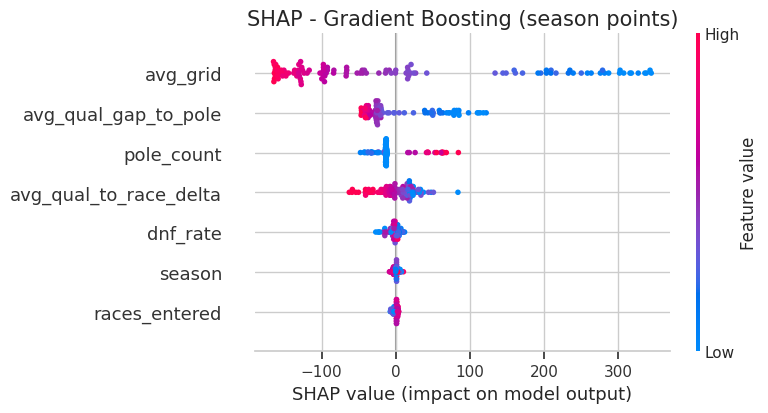

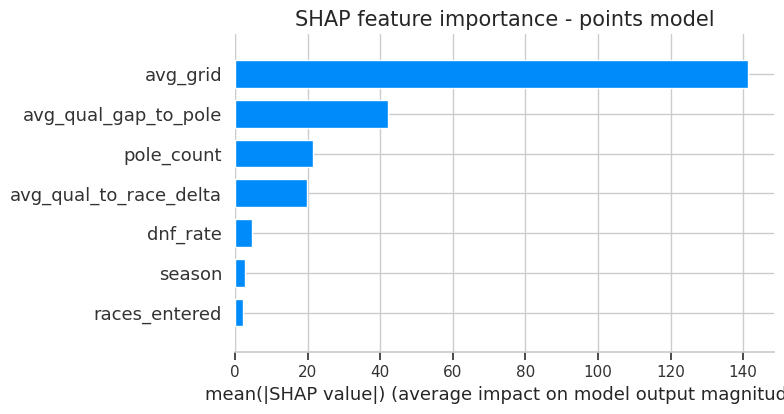

In [ ]:
# --- GBR points model ---
gbr_full = GradientBoostingRegressor(**GBR_CFG).fit(X[train], y[train])
expl = shap.TreeExplainer(gbr_full)
sv   = expl.shap_values(X)

shap.summary_plot(sv, X, show=False)
plt.title('SHAP - Gradient Boosting (season points)', fontsize=15)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/sprint3_01_shap_gbr_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

shap.summary_plot(sv, X, plot_type='bar', show=False)
plt.title('SHAP feature importance - points model', fontsize=15)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/sprint3_02_shap_gbr_bar.png', dpi=150, bbox_inches='tight')
plt.show()

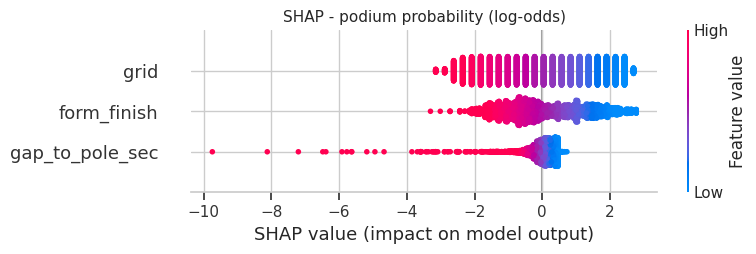

In [ ]:
# --- podium classifier (underlying linear model, standardised) ---
scaler  = StandardScaler().fit(Xp)
Xp_std  = scaler.transform(Xp)
lr_shap = LogisticRegression(max_iter=1000, class_weight='balanced').fit(Xp_std, yp)

lexpl = shap.LinearExplainer(lr_shap, Xp_std)
lsv   = lexpl.shap_values(Xp_std)

shap.summary_plot(lsv, Xp_std, feature_names=PODIUM_FEATURES, show=False)
plt.title('SHAP - podium probability (log-odds)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/sprint3_03_shap_podium_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

**Brand Value Index**

Two dimensions, each the mean of two season-normalised components:

| Dimension | Weight | Components |
| :--- | :--- | :--- |
| **Performance** | 60% | predicted season points · mean podium probability |
| **Consistency** | 40% | reliability (`finish_rate`) · grid-to-finish conversion stability |

Conversion stability is the negative within-season standard deviation of the grid-to-finish delta — a team that turns its grid slot into a finishing position predictably scores high. Min-max normalisation is applied within each season so a dominant era does not crush midfield scores. BVI = 0.60·Performance + 0.40·Consistency, reported on a 0–100 scale.

In [ ]:
# season-level podium probability per constructor
pod_season = (pod.groupby(['season', 'constructor_id'])['oof_podium_prob']
                 .mean().rename('mean_podium_prob').reset_index())

# conversion stability: low volatility of grid-to-finish delta = consistent
conv = (-res.groupby(['season', 'constructor_id'])['delta'].std()) \
            .rename('conversion_stability').reset_index()

bvi = (tsf.merge(pod_season, on=['season', 'constructor_id'], how='left')
          .merge(conv,       on=['season', 'constructor_id'], how='left'))

def minmax_in_season(df, col):
    return df.groupby('season')[col].transform(
        lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else 0.5)

# Performance (60%): predicted points + podium probability
# Consistency (40%): reliability + grid-to-finish conversion stability
for raw, norm in [('pred_points', 'n_points'), ('mean_podium_prob', 'n_podium'),
                  ('finish_rate', 'n_reliability'), ('conversion_stability', 'n_conversion')]:
    bvi[norm] = minmax_in_season(bvi, raw)

bvi['performance_score'] = bvi[['n_points', 'n_podium']].mean(axis=1)
bvi['consistency_score'] = bvi[['n_reliability', 'n_conversion']].mean(axis=1)
bvi['BVI']     = (W_PERFORMANCE * bvi['performance_score']
                  + W_CONSISTENCY * bvi['consistency_score'])
bvi['BVI_100'] = (bvi['BVI'] * 100).round(1)

print(f"BVI computed for {len(bvi)} team-seasons "
      f"(range {bvi['BVI_100'].min():.1f} - {bvi['BVI_100'].max():.1f}).")
bvi[['season', 'name', 'performance_score', 'consistency_score', 'BVI_100']].head()

BVI computed for 112 team-seasons (range 5.0 - 100.0).


,season,name,performance_score,consistency_score,BVI_100
0,2014,Mercedes,1.000000,0.416667,76.7
1,2014,Red Bull,0.446979,0.463270,45.3
2,2014,Williams,0.379892,0.635251,48.2
3,2014,Ferrari,0.273097,0.823723,49.3
4,2014,McLaren,0.240258,0.883297,49.7


In [ ]:
ranking = bvi.sort_values(['season', 'BVI'], ascending=[True, False]).copy()
ranking['bvi_rank']   = ranking.groupby('season')['BVI'].rank(
                            ascending=False, method='min').astype(int)
ranking['champ_rank'] = ranking.groupby('season')['total_points'].rank(
                            ascending=False, method='min').astype(int)

out_cols = ['season', 'bvi_rank', 'name', 'performance_score', 'consistency_score',
            'BVI_100', 'total_points', 'champ_rank']
ranking[out_cols].round(3).to_csv(f'{EXPORTS_DIR}/bvi_scores.csv', index=False)

with sqlite3.connect(DB_PATH) as conn:
    ranking[out_cols + ['mean_podium_prob', 'pred_points']].to_sql(
        'team_season_bvi', conn, if_exists='replace', index=False)
print(f"Saved -> {EXPORTS_DIR}/bvi_scores.csv  and DB table team_season_bvi\n")

latest = ranking[ranking['season'] == TEST_SEASON]
print(f"BVI ranking - {TEST_SEASON}")
print(latest[['bvi_rank', 'name', 'performance_score', 'consistency_score',
              'BVI_100', 'champ_rank']].to_string(index=False))

Saved -> /content/drive/MyDrive/PitWall/data/exports/bvi_scores.csv  and DB table team_season_bvi

BVI ranking - 2024
 bvi_rank           name  performance_score  consistency_score  BVI_100  champ_rank
        1        McLaren           0.901613           0.786797     85.6           1
        2        Ferrari           0.820161           0.648687     75.2           2
        3       Red Bull           0.942217           0.377344     71.6           3
        4       Mercedes           0.535032           0.296007     43.9           4
        5   Aston Martin           0.114969           0.686318     34.4           5
        6   Haas F1 Team           0.035802           0.796007     34.0           7
        7         Sauber           0.004064           0.759758     30.6          10
        8     RB F1 Team           0.042388           0.543381     24.3           8
        9 Alpine F1 Team           0.031016           0.453848     20.0           6
       10       Williams           0.00206

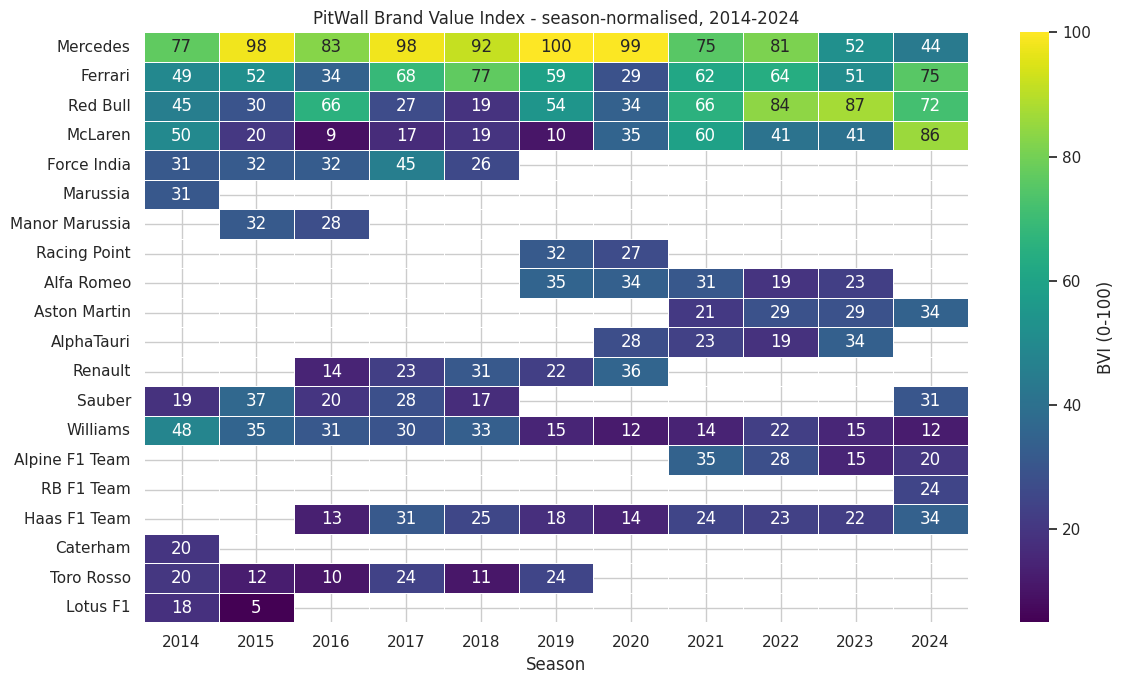

In [ ]:
pivot = bvi.pivot_table(index='name', columns='season', values='BVI_100')
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='viridis',
            linewidths=.5, cbar_kws={'label': 'BVI (0-100)'})
plt.title('PitWall Brand Value Index - season-normalised, 2014-2024')
plt.xlabel('Season'); plt.ylabel('')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/sprint3_04_bvi_heatmap.png', dpi=150)
plt.show()

In [ ]:
# Spearman: the BVI should track the championship without being a copy of it.
rows = []
for s, grp in bvi.groupby('season'):
    rows.append((s, round(grp['BVI'].corr(grp['total_points'], method='spearman'), 3)))
sp = pd.DataFrame(rows, columns=['season', 'spearman_rho'])
print(f"BVI vs championship points - mean Spearman rho: {sp['spearman_rho'].mean():.3f}")
print('(High enough to be credible; below 1.0 because Consistency and the podium '
      'model deliberately move teams off their raw points rank.)\n')

ranking['rank_shift'] = ranking['champ_rank'] - ranking['bvi_rank']
div = ranking.reindex(ranking['rank_shift'].abs().sort_values(ascending=False).index)
print('Largest BVI vs championship divergences:')
print(div[['season', 'name', 'total_points', 'champ_rank', 'bvi_rank',
           'rank_shift']].head(8).to_string(index=False))

BVI vs championship points - mean Spearman rho: 0.718
(High enough to be credible; below 1.0 because Consistency and the podium model deliberately move teams off their raw points rank.)

Largest BVI vs championship divergences:
 season           name  total_points  champ_rank  bvi_rank  rank_shift
   2018       Williams           7.0          10         3           7
   2019        McLaren         145.0           4        10          -6
   2016        McLaren          76.0           6        11          -5
   2015         Sauber          36.0           8         3           5
   2018       Red Bull         419.0           3         8          -5
   2020   Racing Point         210.0           3         8          -5
   2016 Manor Marussia           1.0          11         6           5
   2015 Manor Marussia           0.0          10         6           4


**Sprint 3 — Key Findings**

1. **Points model.** Gradient Boosting scores R² = 0.976 on the held-out 2024
   season (RMSE 38.7). SHAP confirms the Sprint 2 permutation result: `avg_grid`
   dominates, with a mean absolute SHAP value roughly three times that of the
   next feature (`avg_qual_gap_to_pole`) — the near-tautology flagged in Sprint 2
   (grid encodes car pace) made explicit.

2. **Podium classifier.** Held-out 2024 AUC-ROC = 0.928, Brier = 0.071 — well
   ranked and well calibrated. SHAP shows starting `grid` drives podium log-odds
   most strongly, ahead of in-season form (`form_finish`) and qualifying gap
   (`gap_to_pole_sec`).

3. **BVI behaviour.** Mean Spearman ρ vs championship points = 0.718 — correlated
   enough to be credible, loose enough to be doing real work. The Consistency
   dimension is what separates the BVI from a points table: 2018 Williams
   finished 10th on points but ranks 3rd on BVI, a 7-place shift earned by
   reliable grid-to-finish conversion despite a slow car.

4. **Caveat to discuss.** A reliable backmarker scores well on Consistency
   despite low pace; the divergence table makes this visible. Whether that is
   desirable is a sponsorship-framing question for the final report.

---

**Sprint 3 deliverables:** podium classifier ✓ · SHAP attribution ✓ · BVI + `bvi_scores.csv` ✓ → Sprint 4: Streamlit dashboard.